# Supplemental, find kappa for the chromatin

Code to compute the MG1 DG1 measure for finding the optimal kappa for the chromatin.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [272]:
from src.config import load_default_chrom_configs
from src.combined_chromatin_model import CombinedChromatinModel

config1, config2 = load_default_chrom_configs()

combined_model = CombinedChromatinModel(config1=config1, config2=config2)

chrom = 1
mnase_span = 46000, 46100

# Load window to deconvolve
combined_model.load_mnase_span(chrom, mnase_span)
combined_model.setup_deconv_model(copy_correct=False)


Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 99) to (16, 26, 10)
Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 99) to (15, 26, 10)
Loading copy correction N, Fr, B from output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr


In [273]:
combined_model.deconvolve(gamma=0.07, kappa=0.01, eta=0)

0/260 - 00:00:00.000
Completed - 00:00:36.199


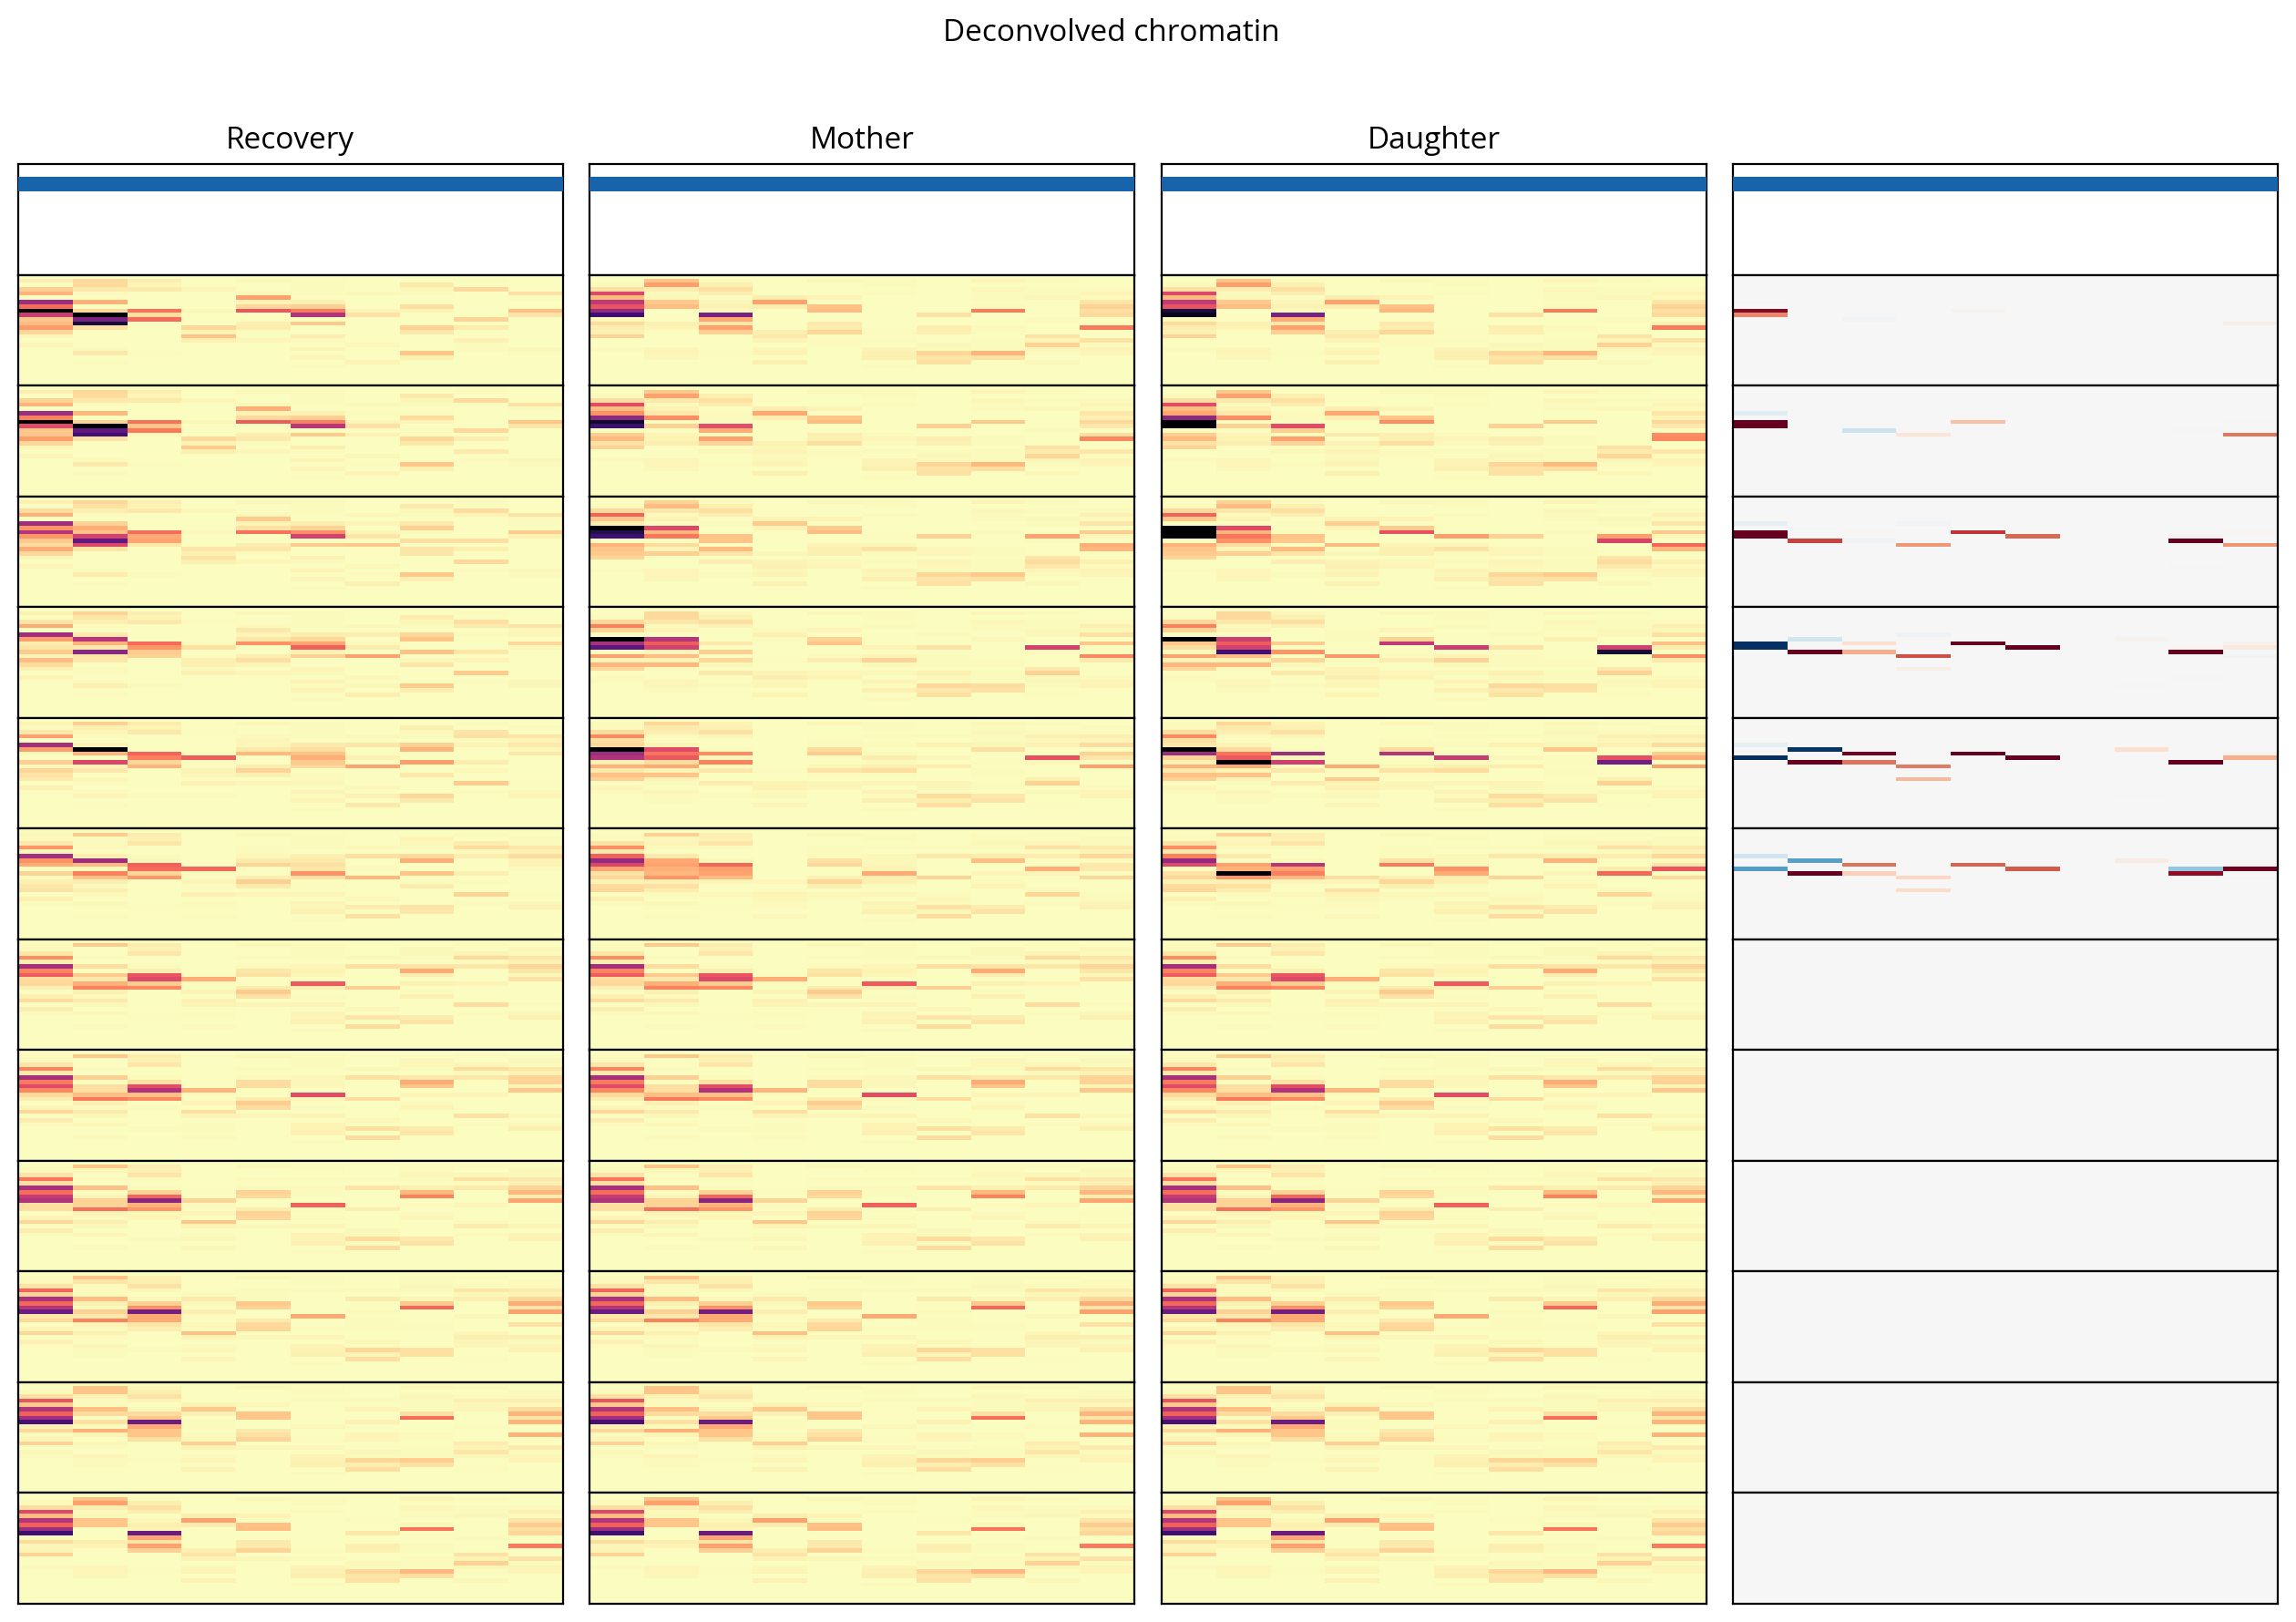

In [274]:
combined_model.plot_branches(figsize=(16, 10))

In [281]:
from src.dg1_mg1_island_analysis import ChromatinOccupancyIslandDetector

# Usage:
detector = ChromatinOccupancyIslandDetector(config1, config2, 
    combined_model.solver.F)
detector.step1_preprocess_data(min_occupancy=1e-3)
_ = detector.step2_analyze_distribution(std_multiplier=1, plot=False)

F_imgs shape: (257, 26, 10)
MG1 shape: (64, 26, 10)
DG1 shape: (64, 26, 10)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 10), DG1: (26, 10)
Total positions: 260
Filtered positions: 174
Filtered percentage: 66.9%
=== Step 2: Distribution Analysis ===
Mean difference: 0.478
Std difference: 2.666
Threshold range: [-2.188, 3.143]


=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 13
Detected 1 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 7
Negative outlier pixels: 1
Detected 1 positive islands
Detected 0 negative islands
Mother/Daughter pixels: 7
Remaining pixels after M/D subtraction: 8
Detected 1 unchanging islands


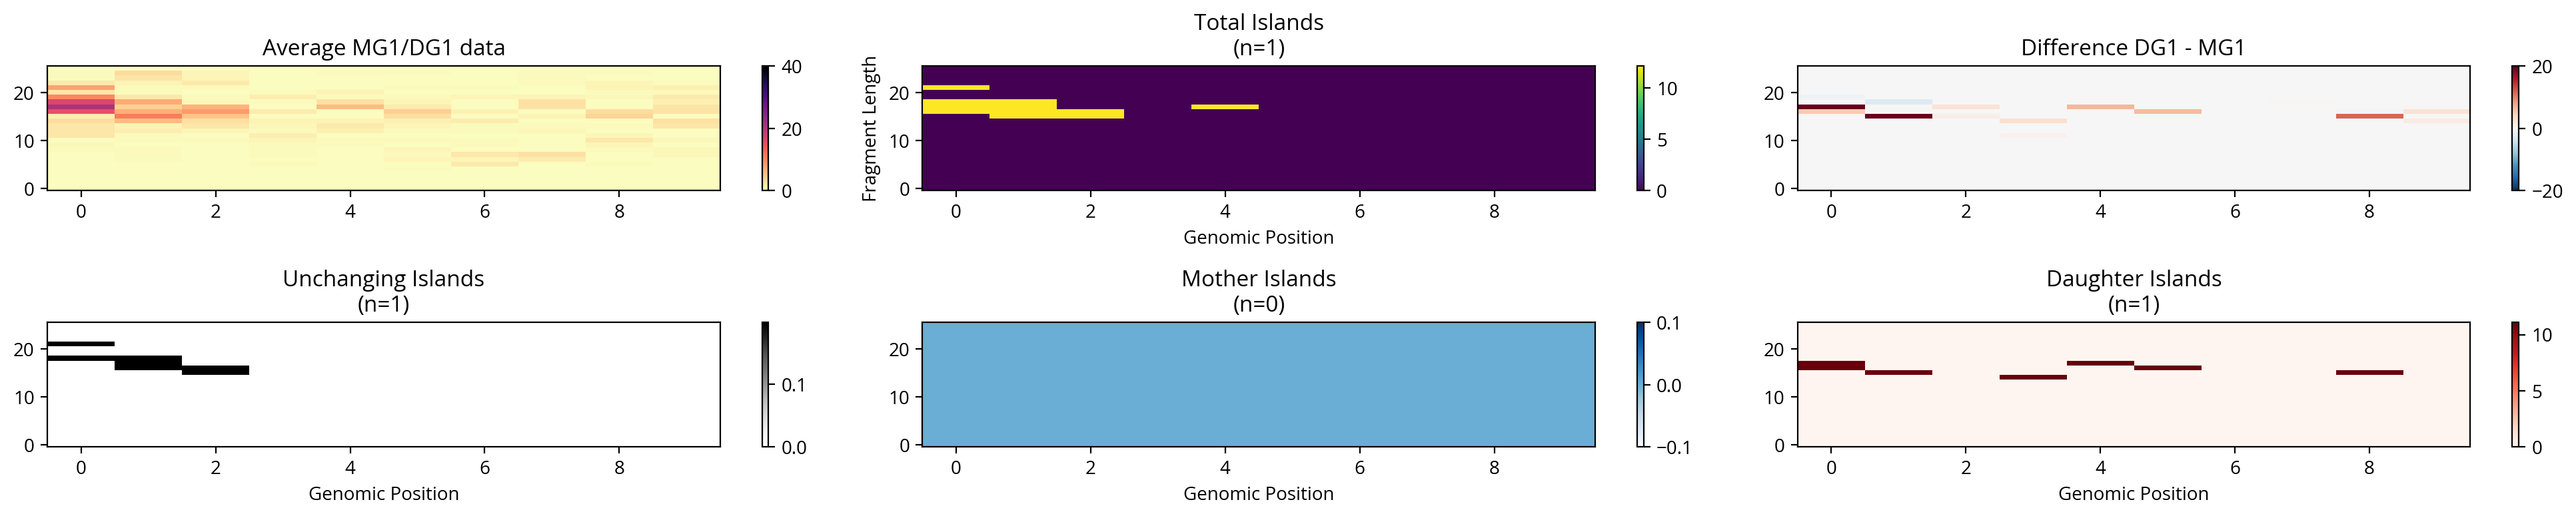

In [282]:
all_islands = detector.detect_all_island_types(max_distance=4, min_size=3,
    occupancy_threshold=5)
detector.plot_all_islands_overview()

In [283]:
_ = detector.comprehensive_summary()


CHROMATIN LANDSCAPE COMPOSITION ANALYSIS

🧬 CHROMATIN BREAKDOWN:
   Total chromatin regions detected: 1 islands
   Genome coverage by chromatin: 4.2%

📊 CHROMATIN COMPOSITION (by island count):
   • Mother-specific:    0.0% (0 islands)
   • Daughter-specific:  50.0% (1 islands)
   • Unchanging:         50.0% (1 islands)

📊 CHROMATIN COMPOSITION (by pixel coverage):
   • Mother-specific:    0.0%
   • Daughter-specific:  50.0%
   • Unchanging:         50.0%


In [285]:
dynamic_percent = detector.composition_stats['dynamics']['dynamic_percent']
print(f"{dynamic_percent:.2f}% "
        "of the chromatin is mother or daughter-specific")

50.00% of the chromatin is mother or daughter-specific


In [337]:
kappa_min = 1e-5
kappa_max = 1
num_kappas = 16

log_kp_start, log_kp_end = np.log2(kappa_min), np.log2(kappa_max)
log_kp_vals = np.linspace(log_kp_start, log_kp_end, num_kappas)
kappa_array = 2**log_kp_vals

In [ ]:
# Now let's try a set of kappa values and observe how the metric changes
dynamic_percentages = []
sns = []
rns = []

for kappa in kappa_array:
    
    combined_model.deconvolve(gamma=0.07, kappa=kappa, eta=0)
    F = combined_model.solver.F
    
    from src.dg1_mg1_island_analysis import ChromatinOccupancyIslandDetector

    detector = ChromatinOccupancyIslandDetector(config1, config2, F)
    detector.step1_preprocess_data(min_occupancy=1e-3)
    _ = detector.step2_analyze_distribution(std_multiplier=1, plot=False)
    all_islands = detector.detect_all_island_types(max_distance=4, min_size=3,
        occupancy_threshold=5)
    
    # Run deconvolution with kappa
    # Run your island detection pipeline
    stats = detector.calculate_chromatin_composition()
    dynamic_percentages.append(stats['dynamics']['dynamic_percent'])
    sns.append(combined_model.solver.sn)
    rns.append(combined_model.solver.rn)


0/260 - 00:00:00.000
Completed - 00:00:33.662
F_imgs shape: (257, 26, 10)
MG1 shape: (64, 26, 10)
DG1 shape: (64, 26, 10)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 10), DG1: (26, 10)
Total positions: 260
Filtered positions: 174
Filtered percentage: 66.9%
=== Step 2: Distribution Analysis ===
Mean difference: 0.793
Std difference: 4.276
Threshold range: [-3.483, 5.069]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 12
Detected 1 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 10
Negative outlier pixels: 3
Detected 1 positive islands
Detected 0 negative islands
Mother/Daughter pixels: 10
Remaining pixels after M/D subtraction: 5
Detected 1 unchanging islands
0/260 - 00:00:00.000
Completed - 00:00:34.635
F_imgs shape: (257, 26, 10)
MG1 shape: (64, 26, 10)
DG1 shape: (64, 26, 10)
=== Step 1: Data Preproces

In [ ]:
plt.figure(figsize=(6, 2))
plt.subplot(1, 2, 1)
# Plot elbow curve
plt.plot(kappa_array, dynamic_percentages, 'o-b')
plt.xscale('log')
plt.xlabel('Kappa (L1 Regularization)')
plt.ylabel('Dynamic Chromatin (%)')

# Keep trakc of rn and sn as well, and observe how kappa affects these values
# I expect low kappa can contribute to poor smoothing. and we need kappa to be high enough
# to stabilize the solution as well.
plt.subplot(1, 2, 2)
plt.plot(sns, rns, 'o-b')